# 第三章：Understanding LSTM Networks
## Christopher Olah 的 LSTM 視覺化解說 - PyTorch 實作

本 Notebook 使用 PyTorch **從零實作** LSTM（Long Short-Term Memory），
並透過視覺化理解其內部閘門機制如何解決梯度消失問題。

In [1]:
# 跨平台中文字型設定（支援 Colab、VSCode、Antigravity 等本地環境）
import subprocess
import os
import shutil
import platform

system = platform.system()

# 必須在 import matplotlib 之前清除快取
cache_dir = os.path.expanduser('~/.matplotlib')
if os.path.exists(cache_dir):
    for f in os.listdir(cache_dir):
        if f.startswith('fontlist'):
            try:
                os.remove(os.path.join(cache_dir, f))
            except:
                pass

cache_dir2 = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir2):
    shutil.rmtree(cache_dir2, ignore_errors=True)

# Linux/Colab 環境安裝中文字型
if system == 'Linux' or 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    try:
        result = subprocess.run(['fc-list', ':lang=zh'], capture_output=True, text=True)
        if 'Noto Sans CJK' not in result.stdout:
            print("正在安裝中文字型...")
            subprocess.run(['apt-get', 'update', '-qq'], capture_output=True)
            subprocess.run(['apt-get', 'install', '-qq', '-y', 'fonts-noto-cjk'], capture_output=True)
            print("中文字型安裝完成，請重新啟動 kernel")
    except:
        pass

print(f"✓ {system} 環境")

✓ Darwin 環境：使用系統內建中文字型


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 重建字型快取並設定中文字型
from matplotlib.font_manager import fontManager
fontManager.__init__()

chinese_fonts = [
    'Heiti TC', 'PingFang TC', 'Noto Sans CJK TC',
    'Heiti SC', 'PingFang SC', 'Noto Sans CJK SC', 
    'Microsoft JhengHei', 'Microsoft YaHei',
    'SimHei', 'WenQuanYi Micro Hei', 'Arial Unicode MS',
]

available_fonts = set(f.name for f in fontManager.ttflist)
selected_font = None
for font in chinese_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [selected_font] + chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✓ 使用中文字型: {selected_font}")
else:
    plt.rcParams['font.sans-serif'] = chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print("⚠ 使用預設字型列表")

import matplotlib as mpl
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# 跨平台中文字型設定
# 字型優先順序：涵蓋 Mac, Windows, Linux, Colab 常見中文字型
chinese_fonts = [
    'Noto Sans CJK TC',      # Linux/Colab/Mac(安裝後)
    'Noto Sans CJK SC',      # Linux/Colab/Mac(安裝後) 簡體
    'Heiti TC',              # Mac 內建 繁體
    'Heiti SC',              # Mac 內建 簡體
    'PingFang TC',           # Mac 內建 繁體
    'PingFang SC',           # Mac 內建 簡體
    'Microsoft JhengHei',    # Windows 微軟正黑體 繁體
    'Microsoft YaHei',       # Windows 微軟雅黑 簡體
    'SimHei',                # Windows 黑體
    'WenQuanYi Micro Hei',   # Linux 文泉驛微米黑
    'Droid Sans Fallback',   # Android/舊版 Linux
    'Arial Unicode MS',      # 跨平台 Unicode 字型
    'DejaVu Sans',           # 後備字型
]

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = chinese_fonts
plt.rcParams['axes.unicode_minus'] = False  # 正確顯示負號

# 驗證字型設定
def verify_chinese_font():
    """驗證中文字型是否正確載入"""
    from matplotlib.font_manager import FontManager
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in chinese_fonts:
        if font in available:
            print(f"✓ 使用中文字型: {font}")
            return font
    print("⚠ 警告：未找到中文字型，中文可能無法正確顯示")
    return None

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 檢查裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch 版本: {torch.__version__}")
print(f"使用裝置: {device}")
verify_chinese_font()

PyTorch 版本: 2.9.1
使用裝置: cpu


Matplotlib is building the font cache; this may take a moment.


✓ 使用中文字型: Heiti TC


'Heiti TC'

## 1. 從零實作 LSTMCell

LSTM 的核心是三個閘門：
1. **遺忘閘（Forget Gate）**：決定從細胞狀態中丟棄什麼資訊
2. **輸入閘（Input Gate）**：決定添加什麼新資訊到細胞狀態
3. **輸出閘（Output Gate）**：決定基於細胞狀態輸出什麼

數學公式：
- $f_t = \sigma(W_f \cdot [x_t, h_{t-1}] + b_f)$ （遺忘閘）
- $i_t = \sigma(W_i \cdot [x_t, h_{t-1}] + b_i)$ （輸入閘）
- $\tilde{C}_t = \tanh(W_C \cdot [x_t, h_{t-1}] + b_C)$ （候選細胞狀態）
- $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$ （細胞狀態更新）
- $o_t = \sigma(W_o \cdot [x_t, h_{t-1}] + b_o)$ （輸出閘）
- $h_t = o_t \odot \tanh(C_t)$ （隱藏狀態）

In [3]:
class LSTMCell(nn.Module):
    """
    從零實作的 LSTM Cell（不使用 nn.LSTMCell）
    
    這個實作讓我們能夠觀察每個閘門的值，
    理解 LSTM 如何控制資訊流動。
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # 合併後的輸入維度：[x_t, h_{t-1}]
        concat_size = input_size + hidden_size
        
        # 遺忘閘參數
        self.Wf = nn.Parameter(torch.randn(hidden_size, concat_size) * 0.01)
        self.bf = nn.Parameter(torch.zeros(hidden_size))
        
        # 輸入閘參數
        self.Wi = nn.Parameter(torch.randn(hidden_size, concat_size) * 0.01)
        self.bi = nn.Parameter(torch.zeros(hidden_size))
        
        # 候選細胞狀態參數
        self.Wc = nn.Parameter(torch.randn(hidden_size, concat_size) * 0.01)
        self.bc = nn.Parameter(torch.zeros(hidden_size))
        
        # 輸出閘參數
        self.Wo = nn.Parameter(torch.randn(hidden_size, concat_size) * 0.01)
        self.bo = nn.Parameter(torch.zeros(hidden_size))
    
    def forward(self, x, h_prev, c_prev):
        """
        LSTM Cell 的前向傳播
        
        參數:
            x: 輸入向量 (batch_size, input_size)
            h_prev: 前一時刻隱藏狀態 (batch_size, hidden_size)
            c_prev: 前一時刻細胞狀態 (batch_size, hidden_size)
        
        回傳:
            h_next: 下一時刻隱藏狀態
            c_next: 下一時刻細胞狀態
            gates: 字典，包含各閘門的值（用於視覺化）
        """
        # 合併輸入和前一時刻隱藏狀態
        concat = torch.cat([x, h_prev], dim=1)
        
        # 遺忘閘：決定要從細胞狀態中丟棄什麼
        f = torch.sigmoid(F.linear(concat, self.Wf, self.bf))
        
        # 輸入閘：決定要存儲什麼新資訊
        i = torch.sigmoid(F.linear(concat, self.Wi, self.bi))
        
        # 候選細胞狀態：可能要添加的新資訊
        c_tilde = torch.tanh(F.linear(concat, self.Wc, self.bc))
        
        # 更新細胞狀態：遺忘舊資訊 + 添加新資訊
        c_next = f * c_prev + i * c_tilde
        
        # 輸出閘：決定輸出什麼
        o = torch.sigmoid(F.linear(concat, self.Wo, self.bo))
        
        # 隱藏狀態：經過輸出閘過濾的細胞狀態
        h_next = o * torch.tanh(c_next)
        
        # 儲存閘門值用於視覺化
        gates = {
            'forget': f.detach(),
            'input': i.detach(),
            'output': o.detach(),
            'candidate': c_tilde.detach()
        }
        
        return h_next, c_next, gates

In [4]:
# 測試 LSTMCell
input_size = 10
hidden_size = 20
batch_size = 1

lstm_cell = LSTMCell(input_size, hidden_size)

# 建立測試輸入
x = torch.randn(batch_size, input_size)
h = torch.zeros(batch_size, hidden_size)
c = torch.zeros(batch_size, hidden_size)

# 前向傳播
h_next, c_next, gates = lstm_cell(x, h, c)

print(f"LSTMCell 初始化完成")
print(f"  輸入維度: {input_size}")
print(f"  隱藏維度: {hidden_size}")
print(f"\n輸出形狀:")
print(f"  隱藏狀態 h: {h_next.shape}")
print(f"  細胞狀態 c: {c_next.shape}")
print(f"\n閘門值範圍:")
print(f"  遺忘閘: [{gates['forget'].min():.3f}, {gates['forget'].max():.3f}]")
print(f"  輸入閘: [{gates['input'].min():.3f}, {gates['input'].max():.3f}]")
print(f"  輸出閘: [{gates['output'].min():.3f}, {gates['output'].max():.3f}]")

LSTMCell 初始化完成
  輸入維度: 10
  隱藏維度: 20

輸出形狀:
  隱藏狀態 h: torch.Size([1, 20])
  細胞狀態 c: torch.Size([1, 20])

閘門值範圍:
  遺忘閘: [0.482, 0.517]
  輸入閘: [0.480, 0.520]
  輸出閘: [0.484, 0.525]


## 2. 完整的 LSTM 網路

將 LSTMCell 封裝成可以處理序列的完整網路：

In [5]:
class LSTM(nn.Module):
    """
    完整的 LSTM 網路，可處理序列輸入
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = LSTMCell(input_size, hidden_size)
        
        # 輸出層
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, inputs):
        """
        處理整個序列
        
        參數:
            inputs: 輸入序列，list of tensors，每個 shape 為 (batch_size, input_size)
        
        回傳:
            output: 最終輸出
            h_states: 所有時間步的隱藏狀態
            c_states: 所有時間步的細胞狀態
            all_gates: 所有時間步的閘門值
        """
        batch_size = inputs[0].shape[0]
        
        # 初始化狀態
        h = torch.zeros(batch_size, self.hidden_size)
        c = torch.zeros(batch_size, self.hidden_size)
        
        # 儲存所有狀態和閘門值
        h_states = []
        c_states = []
        all_gates = {'forget': [], 'input': [], 'output': []}
        
        # 逐時間步處理
        for x in inputs:
            h, c, gates = self.cell(x, h, c)
            h_states.append(h.detach().clone())
            c_states.append(c.detach().clone())
            all_gates['forget'].append(gates['forget'])
            all_gates['input'].append(gates['input'])
            all_gates['output'].append(gates['output'])
        
        # 最終輸出
        output = self.fc(h)
        
        return output, h_states, c_states, all_gates

In [6]:
# 建立 LSTM 模型
input_size = 5
hidden_size = 16
output_size = 5

lstm = LSTM(input_size, hidden_size, output_size)
print(f"LSTM 模型建立完成")
print(f"  架構: {input_size} → {hidden_size} → {output_size}")
print(f"  參數數量: {sum(p.numel() for p in lstm.parameters())}")

LSTM 模型建立完成
  架構: 5 → 16 → 5
  參數數量: 1493


## 3. 長期依賴任務：記憶測試

我們建立一個合成任務來測試 LSTM 的長期記憶能力：
- 序列的第一個元素是重要資訊（one-hot 編碼）
- 中間的元素都是雜訊
- 模型需要在序列結束時輸出第一個元素的值

這正是 LSTM 擅長的場景！

In [7]:
def generate_long_term_dependency_data(seq_length, num_samples, input_size):
    """
    產生長期依賴測試資料
    
    任務：記住序列開頭的資訊，在結尾輸出
    """
    X = []
    y = []
    
    for _ in range(num_samples):
        sequence = []
        
        # 第一個元素是重要資訊（one-hot）
        first_elem = np.random.randint(0, input_size)
        first_vec = torch.zeros(1, input_size)
        first_vec[0, first_elem] = 1.0
        sequence.append(first_vec)
        
        # 其餘元素是雜訊
        for _ in range(seq_length - 1):
            noise = torch.randn(1, input_size) * 0.1
            sequence.append(noise)
        
        X.append(sequence)
        
        # 目標：輸出第一個元素
        target = torch.zeros(1, input_size)
        target[0, first_elem] = 1.0
        y.append(target)
    
    return X, y

# 產生測試資料
seq_length = 15
X_test, y_test = generate_long_term_dependency_data(seq_length, 10, input_size)

# 測試前向傳播
output, h_states, c_states, gate_values = lstm(X_test[0])

print(f"測試序列長度: {seq_length}")
print(f"第一個元素（需記憶）: {torch.argmax(X_test[0][0]).item()}")
print(f"期望輸出: {torch.argmax(y_test[0]).item()}")
print(f"模型輸出（未訓練）: {output.detach().numpy().flatten()}")

測試序列長度: 15
第一個元素（需記憶）: 3
期望輸出: 3
模型輸出（未訓練）: [ 0.03820373  0.15250516  0.18854536  0.07854421 -0.00138066]


## 4. 視覺化 LSTM 閘門

理解 LSTM 的關鍵是觀察閘門如何隨時間變化。
讓我們用熱力圖來視覺化各個閘門的活動：

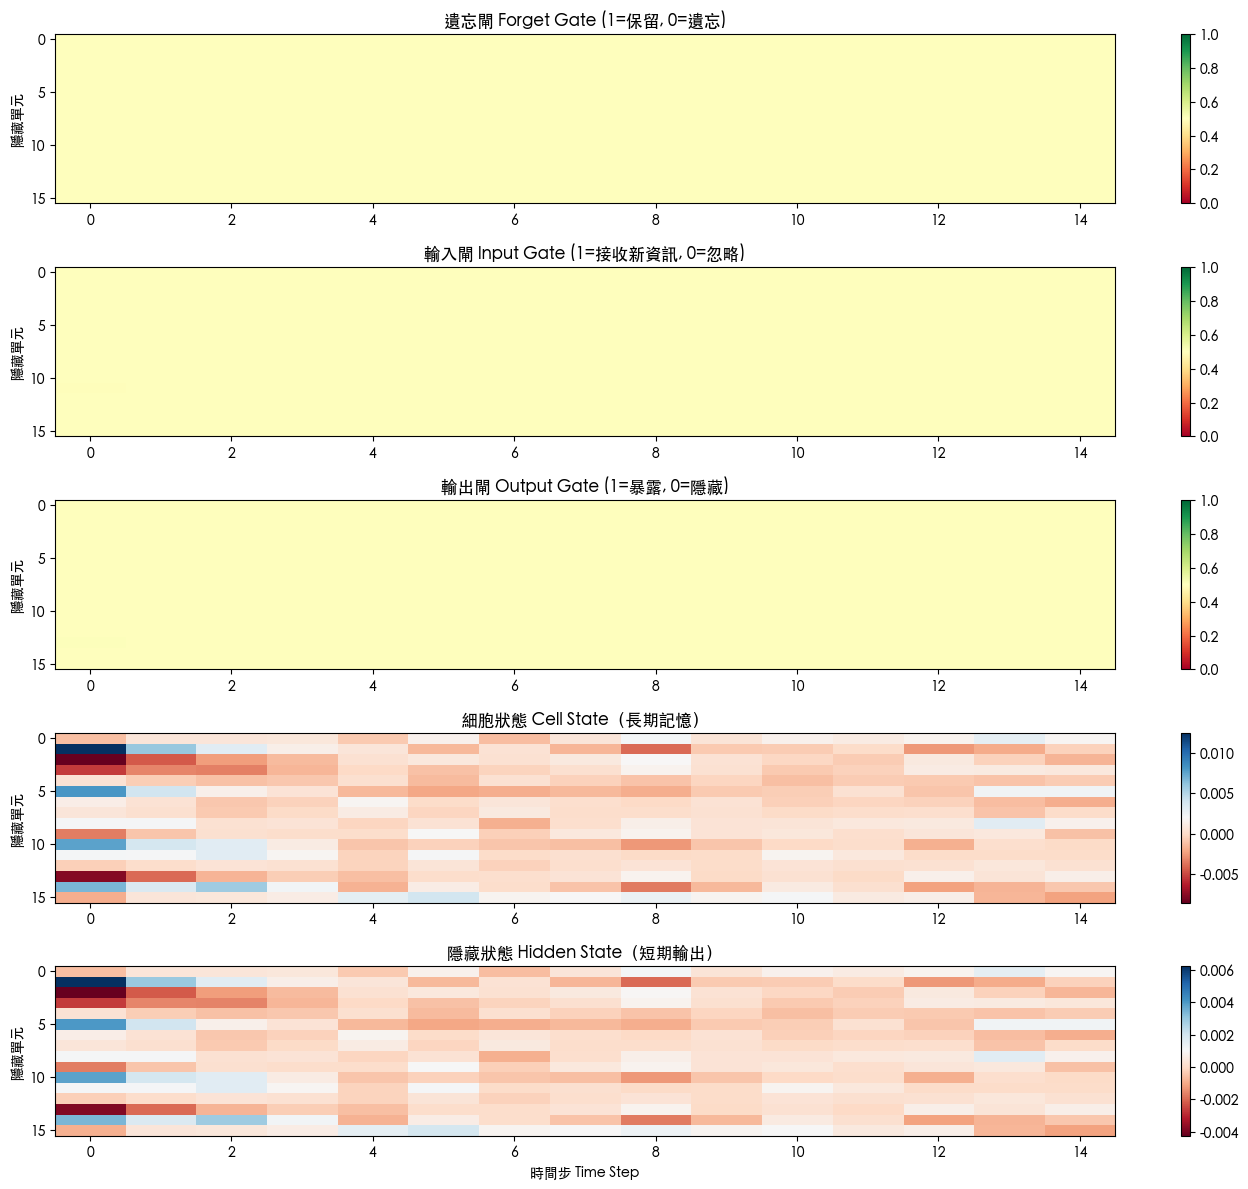


閘門解讀：
• 遺忘閘控制要從細胞狀態中丟棄什麼資訊
• 輸入閘控制要添加什麼新資訊到細胞狀態
• 輸出閘控制要從細胞狀態輸出什麼
• 細胞狀態是長期記憶的『高速公路』


In [8]:
def visualize_lstm_gates(gate_values, c_states, h_states):
    """
    視覺化 LSTM 的閘門和狀態
    """
    # 將列表轉換為矩陣（時間 x 隱藏單元）
    forget_gates = torch.cat(gate_values['forget'], dim=0).numpy().T
    input_gates = torch.cat(gate_values['input'], dim=0).numpy().T
    output_gates = torch.cat(gate_values['output'], dim=0).numpy().T
    cell_states = torch.cat(c_states, dim=0).numpy().T
    hidden_states = torch.cat(h_states, dim=0).numpy().T
    
    fig, axes = plt.subplots(5, 1, figsize=(14, 12))
    
    # 遺忘閘
    im0 = axes[0].imshow(forget_gates, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    axes[0].set_title('遺忘閘 Forget Gate (1=保留, 0=遺忘)', fontsize=12)
    axes[0].set_ylabel('隱藏單元')
    plt.colorbar(im0, ax=axes[0])
    
    # 輸入閘
    im1 = axes[1].imshow(input_gates, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    axes[1].set_title('輸入閘 Input Gate (1=接收新資訊, 0=忽略)', fontsize=12)
    axes[1].set_ylabel('隱藏單元')
    plt.colorbar(im1, ax=axes[1])
    
    # 輸出閘
    im2 = axes[2].imshow(output_gates, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    axes[2].set_title('輸出閘 Output Gate (1=暴露, 0=隱藏)', fontsize=12)
    axes[2].set_ylabel('隱藏單元')
    plt.colorbar(im2, ax=axes[2])
    
    # 細胞狀態
    im3 = axes[3].imshow(cell_states, cmap='RdBu', aspect='auto')
    axes[3].set_title('細胞狀態 Cell State（長期記憶）', fontsize=12)
    axes[3].set_ylabel('隱藏單元')
    plt.colorbar(im3, ax=axes[3])
    
    # 隱藏狀態
    im4 = axes[4].imshow(hidden_states, cmap='RdBu', aspect='auto')
    axes[4].set_title('隱藏狀態 Hidden State（短期輸出）', fontsize=12)
    axes[4].set_ylabel('隱藏單元')
    axes[4].set_xlabel('時間步 Time Step')
    plt.colorbar(im4, ax=axes[4])
    
    plt.tight_layout()
    plt.savefig('lstm_gates_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n閘門解讀：")
    print("• 遺忘閘控制要從細胞狀態中丟棄什麼資訊")
    print("• 輸入閘控制要添加什麼新資訊到細胞狀態")
    print("• 輸出閘控制要從細胞狀態輸出什麼")
    print("• 細胞狀態是長期記憶的『高速公路』")

# 視覺化
visualize_lstm_gates(gate_values, c_states, h_states)

## 5. 比較 LSTM 與 Vanilla RNN

為了理解 LSTM 的優勢，讓我們實作一個 Vanilla RNN 進行比較：

In [9]:
class VanillaRNNCell(nn.Module):
    """
    從零實作的 Vanilla RNN Cell
    
    公式：h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b_h)
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        concat_size = input_size + hidden_size
        self.Wh = nn.Parameter(torch.randn(hidden_size, concat_size) * 0.01)
        self.bh = nn.Parameter(torch.zeros(hidden_size))
        self.hidden_size = hidden_size
    
    def forward(self, x, h_prev):
        concat = torch.cat([x, h_prev], dim=1)
        h_next = torch.tanh(F.linear(concat, self.Wh, self.bh))
        return h_next

class VanillaRNN(nn.Module):
    """
    完整的 Vanilla RNN 網路
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = VanillaRNNCell(input_size, hidden_size)
    
    def forward(self, inputs):
        batch_size = inputs[0].shape[0]
        h = torch.zeros(batch_size, self.hidden_size)
        h_states = []
        
        for x in inputs:
            h = self.cell(x, h)
            h_states.append(h.detach().clone())
        
        return h_states

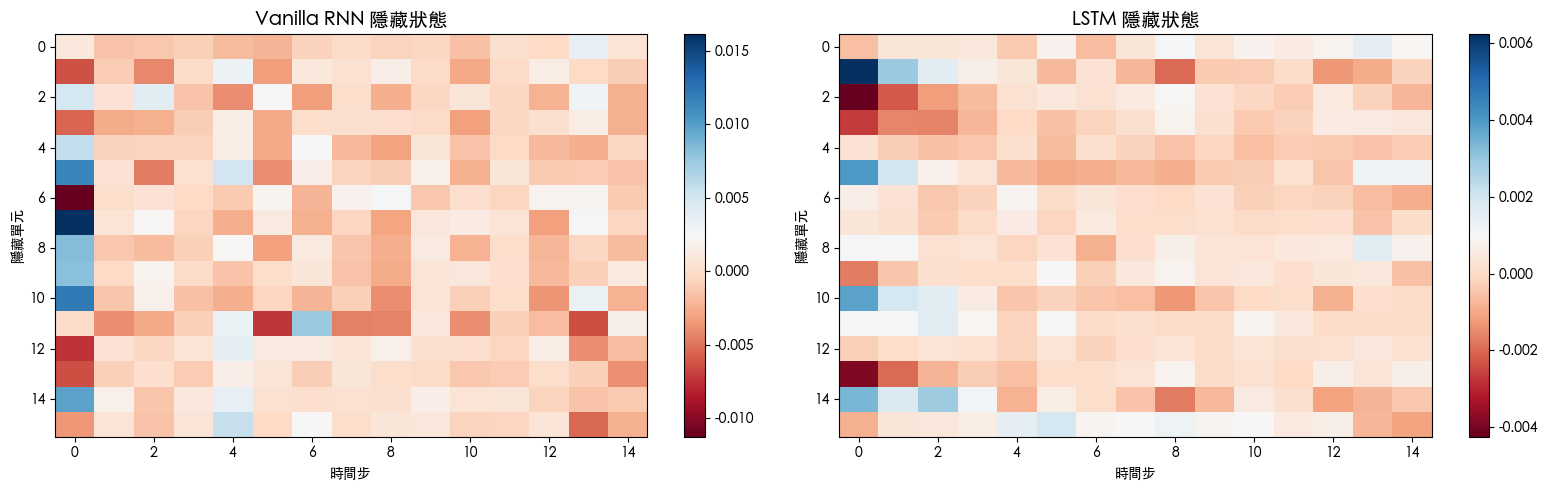


關鍵差異：
• LSTM 的細胞狀態與隱藏狀態分離
• 閘門機制允許選擇性的資訊流動
• 更穩定的梯度流動（解決梯度消失問題）


In [10]:
# 建立 Vanilla RNN 進行比較
vanilla_rnn = VanillaRNN(input_size, hidden_size)

# 使用相同的輸入序列
rnn_h_states = vanilla_rnn(X_test[0])

# 轉換為矩陣
rnn_hidden = torch.cat(rnn_h_states, dim=0).numpy().T
lstm_hidden = torch.cat(h_states, dim=0).numpy().T

# 比較視覺化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

im1 = ax1.imshow(rnn_hidden, cmap='RdBu', aspect='auto')
ax1.set_title('Vanilla RNN 隱藏狀態', fontsize=14)
ax1.set_ylabel('隱藏單元')
ax1.set_xlabel('時間步')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(lstm_hidden, cmap='RdBu', aspect='auto')
ax2.set_title('LSTM 隱藏狀態', fontsize=14)
ax2.set_ylabel('隱藏單元')
ax2.set_xlabel('時間步')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.savefig('rnn_vs_lstm_states.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n關鍵差異：")
print("• LSTM 的細胞狀態與隱藏狀態分離")
print("• 閘門機制允許選擇性的資訊流動")
print("• 更穩定的梯度流動（解決梯度消失問題）")

## 6. 梯度流動比較

LSTM 最重要的特性是它如何處理梯度。
讓我們模擬並比較 Vanilla RNN 和 LSTM 的梯度流動：

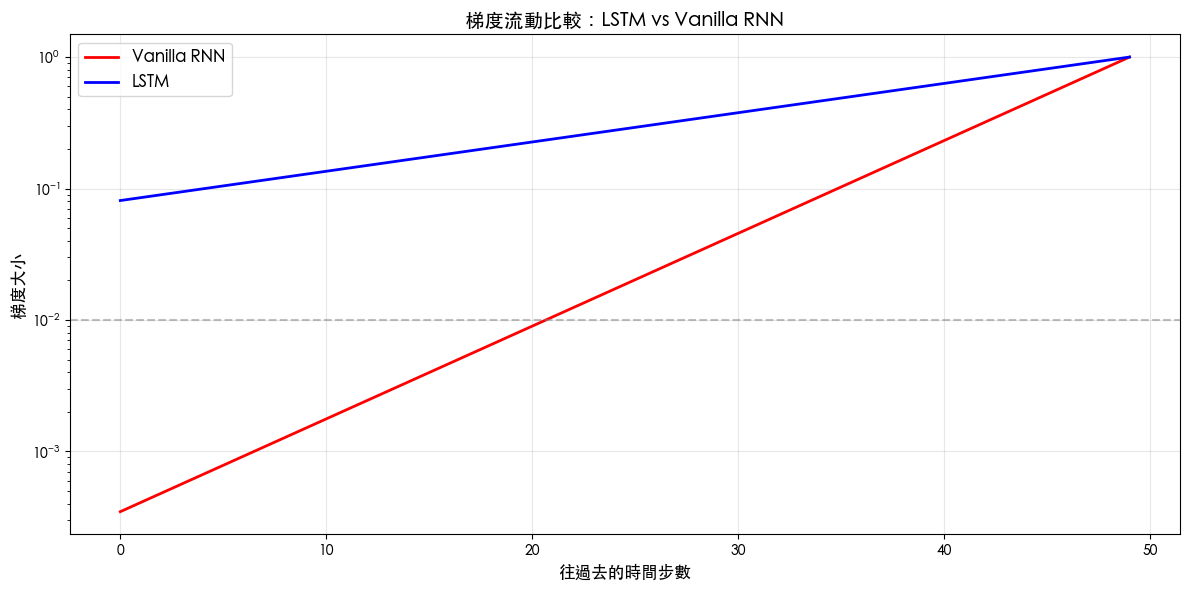


50 步後的梯度：
  Vanilla RNN: 0.0003479584 （消失！）
  LSTM: 0.080995 （保留！）

這就是為什麼 LSTM 能學習長期依賴關係！


In [11]:
def simulate_gradient_flow(seq_length=50):
    """
    模擬梯度如何在 Vanilla RNN 和 LSTM 中衰減
    
    Vanilla RNN: 梯度指數衰減
    LSTM: 梯度通過細胞狀態「高速公路」保持
    """
    # Vanilla RNN: 梯度指數衰減
    # 每一步乘以 tanh 的導數（約 0.7-0.9）和權重矩陣的奇異值
    rnn_grads = []
    grad = 1.0
    decay_factor = 0.85  # 典型的衰減因子
    
    for t in range(seq_length):
        rnn_grads.append(grad)
        grad *= decay_factor
    
    # LSTM: 梯度通過遺忘閘保持
    # 當 f ≈ 1 時，梯度幾乎完整保留
    lstm_grads = []
    grad = 1.0
    forget_gate_avg = 0.95  # 高遺忘閘值 = 保留梯度
    
    for t in range(seq_length):
        lstm_grads.append(grad)
        grad *= forget_gate_avg
    
    return np.array(rnn_grads), np.array(lstm_grads)

# 模擬梯度流動
seq_length = 50
rnn_grads, lstm_grads = simulate_gradient_flow(seq_length)

# 視覺化
plt.figure(figsize=(12, 6))

# 反轉順序：顯示梯度從輸出回傳到輸入
plt.plot(range(seq_length), rnn_grads[::-1], 'r-', 
         label='Vanilla RNN', linewidth=2)
plt.plot(range(seq_length), lstm_grads[::-1], 'b-', 
         label='LSTM', linewidth=2)

plt.xlabel('往過去的時間步數', fontsize=12)
plt.ylabel('梯度大小', fontsize=12)
plt.title('梯度流動比較：LSTM vs Vanilla RNN', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='消失閾值')

plt.tight_layout()
plt.savefig('gradient_flow_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{seq_length} 步後的梯度：")
print(f"  Vanilla RNN: {rnn_grads[-1]:.10f} （消失！）")
print(f"  LSTM: {lstm_grads[-1]:.6f} （保留！）")
print(f"\n這就是為什麼 LSTM 能學習長期依賴關係！")

## 7. 細胞狀態的「高速公路」

LSTM 的核心創新是細胞狀態的更新方式：

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

這是**加法更新**，不是乘法！當 $f_t \approx 1$ 且 $i_t \approx 0$ 時，
$C_t \approx C_{t-1}$，資訊直接流過。

展示細胞狀態的『高速公路』特性

初始細胞狀態: [ 1.  -0.5  0.8 -0.3]


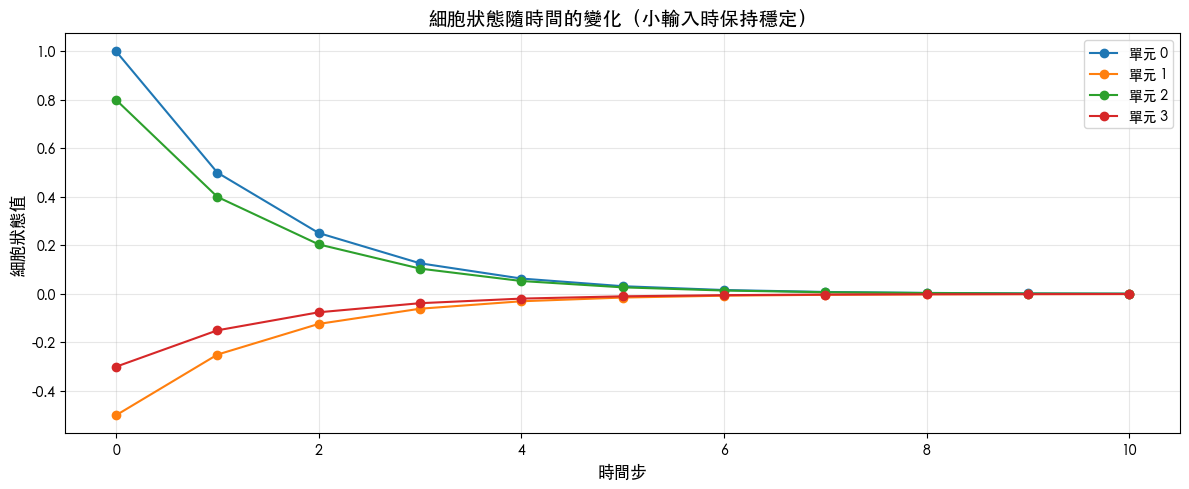


10 步後的平均變化: 0.6493
（由於遺忘閘 ≈ 0.5，細胞狀態會逐漸變化）

當網路學會在需要時將遺忘閘設為 ≈1，
資訊可以幾乎無損地穿越任意長的序列！


In [12]:
def demonstrate_cell_state_highway():
    """
    展示細胞狀態如何像「高速公路」一樣讓資訊流動
    """
    # 建立一個簡單的 LSTM cell
    cell = LSTMCell(input_size=3, hidden_size=4)
    
    # 初始化一個有意義的細胞狀態
    c = torch.tensor([[1.0, -0.5, 0.8, -0.3]])
    h = torch.zeros(1, 4)
    
    print("展示細胞狀態的『高速公路』特性")
    print("="*50)
    print(f"\n初始細胞狀態: {c.numpy().flatten()}")
    
    # 模擬多個時間步，觀察細胞狀態變化
    c_history = [c.clone()]
    
    for t in range(10):
        # 輸入很小的雜訊
        x = torch.randn(1, 3) * 0.01
        h, c, gates = cell(x, h, c)
        c_history.append(c.clone())
    
    # 視覺化細胞狀態隨時間的變化
    c_array = torch.cat(c_history, dim=0).detach().numpy()
    
    plt.figure(figsize=(12, 5))
    for i in range(4):
        plt.plot(c_array[:, i], marker='o', label=f'單元 {i}')
    
    plt.xlabel('時間步', fontsize=12)
    plt.ylabel('細胞狀態值', fontsize=12)
    plt.title('細胞狀態隨時間的變化（小輸入時保持穩定）', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('cell_state_highway.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 計算變化量
    total_change = np.abs(c_array[-1] - c_array[0]).mean()
    print(f"\n10 步後的平均變化: {total_change:.4f}")
    print("（由於遺忘閘 ≈ 0.5，細胞狀態會逐漸變化）")
    print("\n當網路學會在需要時將遺忘閘設為 ≈1，")
    print("資訊可以幾乎無損地穿越任意長的序列！")

demonstrate_cell_state_highway()

## 8. 閘門學習示範

讓我們訓練一個小型 LSTM 來學習記住序列開頭的資訊，
並觀察閘門如何變化：

In [13]:
def train_lstm_memory_task(seq_length=20, num_epochs=200, verbose=True):
    """
    訓練 LSTM 完成長期記憶任務
    """
    # 建立模型
    input_size = 5
    hidden_size = 16
    output_size = 5
    
    model = LSTM(input_size, hidden_size, output_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    # 產生訓練資料
    X_train, y_train = generate_long_term_dependency_data(
        seq_length, num_samples=100, input_size=input_size)
    
    losses = []
    accuracies = []
    
    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        
        for i in range(len(X_train)):
            optimizer.zero_grad()
            
            output, _, _, _ = model(X_train[i])
            target = torch.argmax(y_train[i], dim=1)
            
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            pred = torch.argmax(output, dim=1)
            correct += (pred == target).sum().item()
        
        avg_loss = total_loss / len(X_train)
        accuracy = correct / len(X_train)
        losses.append(avg_loss)
        accuracies.append(accuracy)
        
        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2%}")
    
    return model, losses, accuracies

# 訓練模型
print(f"訓練 LSTM 完成長期記憶任務（序列長度=20）")
print("="*50)
trained_lstm, losses, accuracies = train_lstm_memory_task(seq_length=20)

訓練 LSTM 完成長期記憶任務（序列長度=20）
Epoch  20: Loss = 1.1271, Accuracy = 55.00%
Epoch  40: Loss = 0.2720, Accuracy = 93.00%
Epoch  60: Loss = 0.3269, Accuracy = 89.00%
Epoch  80: Loss = 0.0158, Accuracy = 100.00%
Epoch 100: Loss = 0.3854, Accuracy = 86.00%
Epoch 120: Loss = 0.0018, Accuracy = 100.00%
Epoch 140: Loss = 0.0003, Accuracy = 100.00%
Epoch 160: Loss = 0.0001, Accuracy = 100.00%
Epoch 180: Loss = 0.0000, Accuracy = 100.00%
Epoch 200: Loss = 0.0000, Accuracy = 100.00%


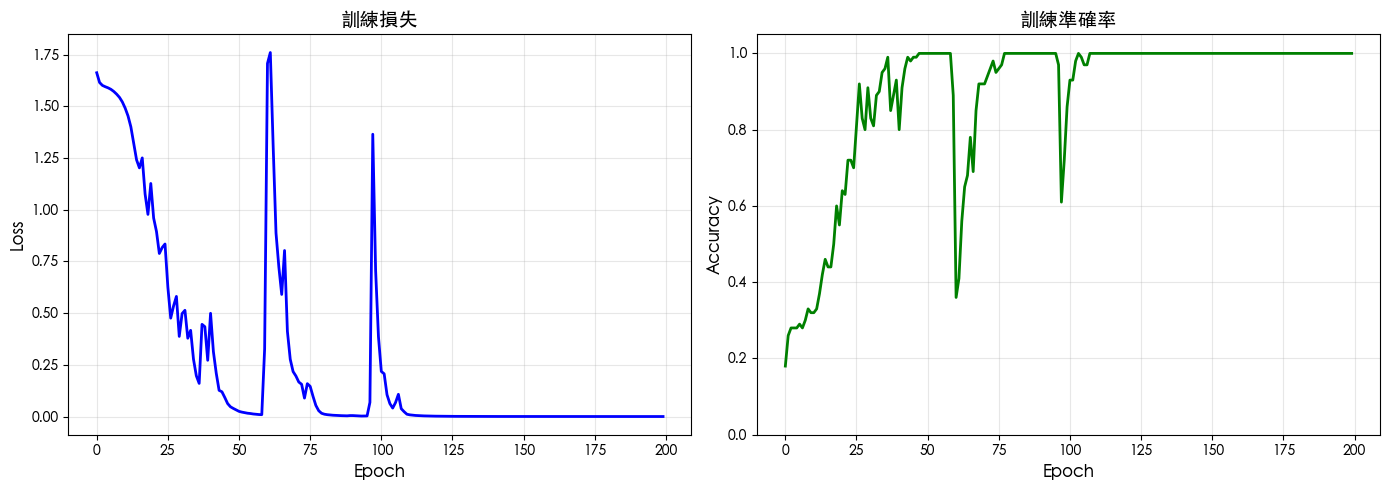


最終準確率: 100.00%
LSTM 成功學會了在 20 個時間步後記住開頭的資訊！


In [14]:
# 視覺化訓練過程
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses, 'b-', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('訓練損失', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.plot(accuracies, 'g-', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('訓練準確率', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('lstm_training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n最終準確率: {accuracies[-1]:.2%}")
print("LSTM 成功學會了在 20 個時間步後記住開頭的資訊！")

訓練後的閘門行為視覺化


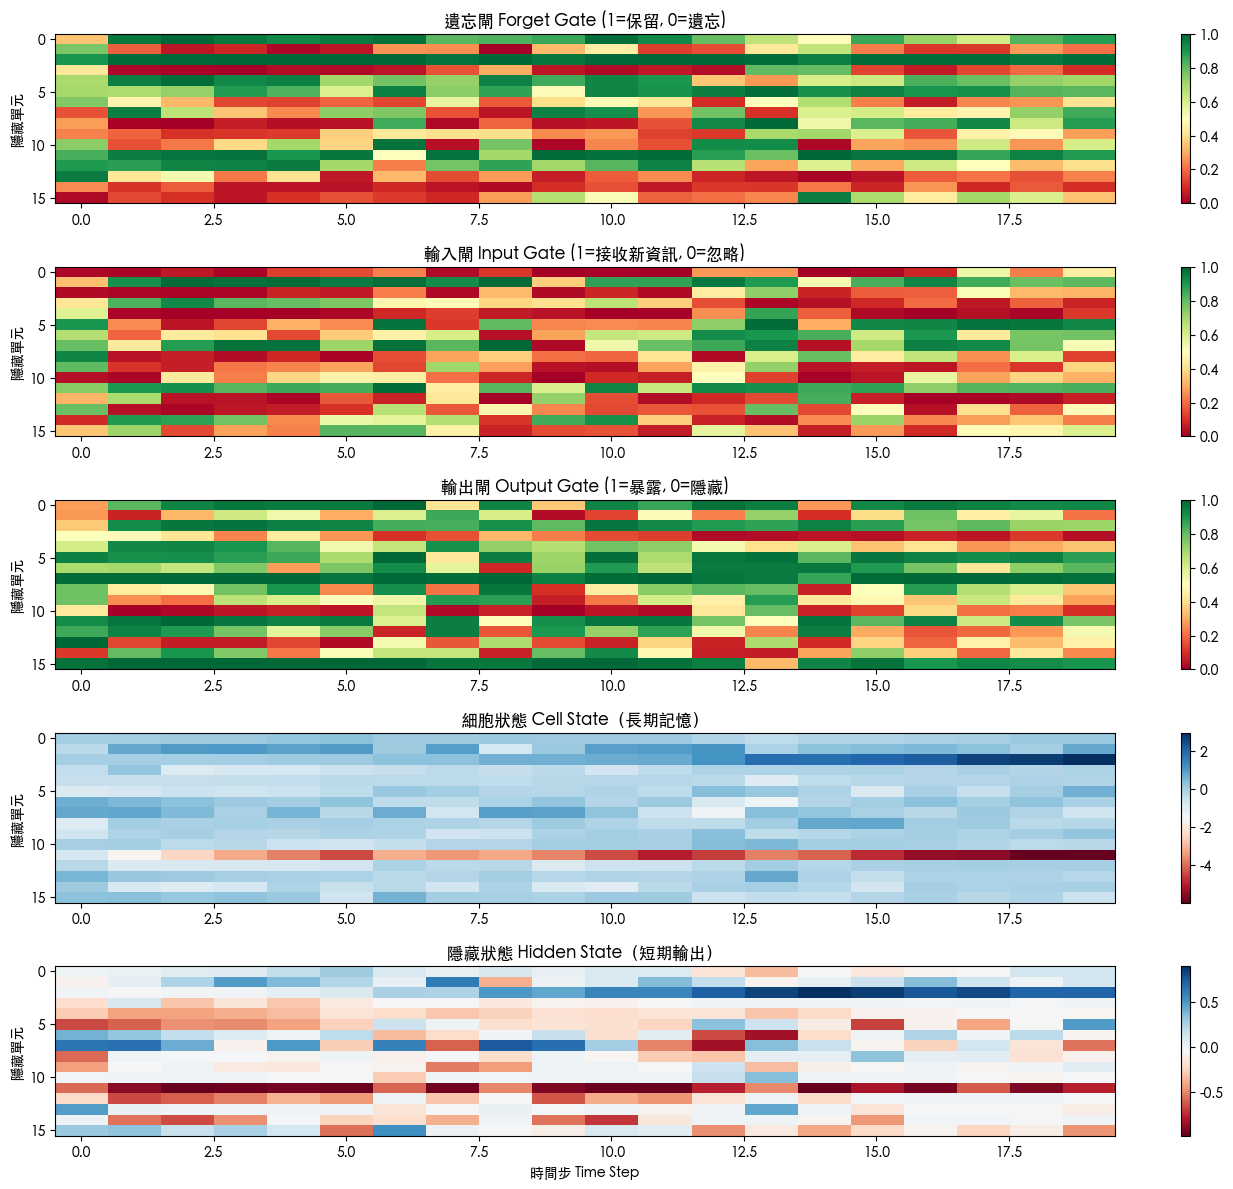


閘門解讀：
• 遺忘閘控制要從細胞狀態中丟棄什麼資訊
• 輸入閘控制要添加什麼新資訊到細胞狀態
• 輸出閘控制要從細胞狀態輸出什麼
• 細胞狀態是長期記憶的『高速公路』

測試結果:
  需記憶的元素: 0
  模型預測: 1
  預測正確: False


In [15]:
# 視覺化訓練後的閘門行為
X_test, y_test = generate_long_term_dependency_data(20, 1, 5)
output, h_states, c_states, gate_values = trained_lstm(X_test[0])

print("訓練後的閘門行為視覺化")
print("="*50)
visualize_lstm_gates(gate_values, c_states, h_states)

print(f"\n測試結果:")
print(f"  需記憶的元素: {torch.argmax(X_test[0][0]).item()}")
print(f"  模型預測: {torch.argmax(output).item()}")
print(f"  預測正確: {torch.argmax(X_test[0][0]).item() == torch.argmax(output).item()}")

## 9. GRU：LSTM 的簡化變體

GRU（Gated Recurrent Unit）是 LSTM 的簡化版本，只有兩個閘門：

- **重置閘（Reset Gate）**：決定如何結合新輸入與舊記憶
- **更新閘（Update Gate）**：決定保留多少舊資訊

GRU 將細胞狀態和隱藏狀態合併為單一狀態。

In [16]:
class GRUCell(nn.Module):
    """
    從零實作的 GRU Cell
    
    公式:
    z_t = σ(W_z · [x_t, h_{t-1}])  # 更新閘
    r_t = σ(W_r · [x_t, h_{t-1}])  # 重置閘
    h̃_t = tanh(W_h · [x_t, r_t ⊙ h_{t-1}])  # 候選隱藏狀態
    h_t = (1 - z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t  # 最終隱藏狀態
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        concat_size = input_size + hidden_size
        
        # 更新閘
        self.Wz = nn.Parameter(torch.randn(hidden_size, concat_size) * 0.01)
        self.bz = nn.Parameter(torch.zeros(hidden_size))
        
        # 重置閘
        self.Wr = nn.Parameter(torch.randn(hidden_size, concat_size) * 0.01)
        self.br = nn.Parameter(torch.zeros(hidden_size))
        
        # 候選隱藏狀態
        self.Wh = nn.Parameter(torch.randn(hidden_size, concat_size) * 0.01)
        self.bh = nn.Parameter(torch.zeros(hidden_size))
        
        self.hidden_size = hidden_size
    
    def forward(self, x, h_prev):
        concat = torch.cat([x, h_prev], dim=1)
        
        # 更新閘：決定更新多少
        z = torch.sigmoid(F.linear(concat, self.Wz, self.bz))
        
        # 重置閘：決定忽略多少舊狀態
        r = torch.sigmoid(F.linear(concat, self.Wr, self.br))
        
        # 候選隱藏狀態
        concat_reset = torch.cat([x, r * h_prev], dim=1)
        h_tilde = torch.tanh(F.linear(concat_reset, self.Wh, self.bh))
        
        # 最終隱藏狀態：混合舊狀態和候選狀態
        h_next = (1 - z) * h_prev + z * h_tilde
        
        return h_next, z, r

# 測試 GRU
gru_cell = GRUCell(input_size=10, hidden_size=20)
x = torch.randn(1, 10)
h = torch.zeros(1, 20)

h_next, z, r = gru_cell(x, h)

print("GRU Cell 測試")
print(f"  輸入維度: 10")
print(f"  隱藏維度: 20")
print(f"  輸出 h 形狀: {h_next.shape}")
print(f"  更新閘 z 範圍: [{z.min():.3f}, {z.max():.3f}]")
print(f"  重置閘 r 範圍: [{r.min():.3f}, {r.max():.3f}]")
print(f"\nGRU 參數數量: {sum(p.numel() for p in gru_cell.parameters())}")
print(f"LSTM 參數數量: {sum(p.numel() for p in lstm_cell.parameters())}")
print("\nGRU 比 LSTM 少了約 25% 的參數！")

GRU Cell 測試
  輸入維度: 10
  隱藏維度: 20
  輸出 h 形狀: torch.Size([1, 20])
  更新閘 z 範圍: [0.477, 0.528]
  重置閘 r 範圍: [0.485, 0.525]

GRU 參數數量: 1860
LSTM 參數數量: 2480

GRU 比 LSTM 少了約 25% 的參數！


## 10. 使用 PyTorch 內建的 LSTM

在實際應用中，我們通常使用 PyTorch 優化過的 `nn.LSTM`：

In [17]:
# 使用 PyTorch 內建 LSTM
class PyTorchLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 使用 PyTorch 內建的 LSTM
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        # 初始化隱藏狀態
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        
        # LSTM 前向傳播
        out, (hn, cn) = self.lstm(x, (h0, c0))
        
        # 取最後一個時間步的輸出
        out = self.fc(out[:, -1, :])
        return out

# 測試內建 LSTM
pytorch_lstm = PyTorchLSTM(input_size=5, hidden_size=16, output_size=5)

# 建立批次輸入
batch_input = torch.randn(8, 20, 5)  # (batch=8, seq_len=20, features=5)
output = pytorch_lstm(batch_input)

print("PyTorch 內建 LSTM 測試")
print(f"  輸入形狀: {batch_input.shape}")
print(f"  輸出形狀: {output.shape}")
print(f"\n內建 LSTM 的優點：")
print("  • cuDNN 加速（GPU 上更快）")
print("  • 支援多層堆疊")
print("  • 支援雙向 LSTM")
print("  • 記憶體效率更高")

PyTorch 內建 LSTM 測試
  輸入形狀: torch.Size([8, 20, 5])
  輸出形狀: torch.Size([8, 5])

內建 LSTM 的優點：
  • cuDNN 加速（GPU 上更快）
  • 支援多層堆疊
  • 支援雙向 LSTM
  • 記憶體效率更高


## 11. 總結

### LSTM 架構的核心概念

| 組件 | 功能 | 解決的問題 |
|------|------|------------|
| 細胞狀態 C | 長期記憶的「高速公路」 | 資訊可以無損穿越長序列 |
| 遺忘閘 f | 決定丟棄什麼 | 選擇性地清除不需要的資訊 |
| 輸入閘 i | 決定添加什麼 | 選擇性地接收新資訊 |
| 輸出閘 o | 決定輸出什麼 | 控制當前時刻的輸出 |

### LSTM 為何能解決梯度消失

1. **加法更新**：$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$
   - 不是連續的矩陣乘法
   - 梯度可以直接流過細胞狀態

2. **遺忘閘控制**：當 $f_t \approx 1$
   - 細胞狀態幾乎不變
   - 梯度也幾乎不衰減

3. **常數錯誤輪播**（Constant Error Carousel）
   - 細胞狀態提供了梯度的「高速公路」
   - 允許學習跨越 100+ 時間步的依賴

### 實際應用

- 機器翻譯
- 語音識別
- 文本生成
- 時間序列預測
- 影片分析

In [18]:
print("第三章完成！")
print("\n我們學到了：")
print("  1. LSTM 如何透過閘門機制控制資訊流動")
print("  2. 細胞狀態如何作為長期記憶的『高速公路』")
print("  3. 為什麼 LSTM 能解決梯度消失問題")
print("  4. LSTM 與 Vanilla RNN 的差異")
print("  5. GRU 作為 LSTM 的簡化變體")
print("\n下一章我們將學習更多經典的深度學習論文！")

第三章完成！

我們學到了：
  1. LSTM 如何透過閘門機制控制資訊流動
  2. 細胞狀態如何作為長期記憶的『高速公路』
  3. 為什麼 LSTM 能解決梯度消失問題
  4. LSTM 與 Vanilla RNN 的差異
  5. GRU 作為 LSTM 的簡化變體

下一章我們將學習更多經典的深度學習論文！
